## Import the Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

## Loading the Dataset

In [2]:
df = pd.read_csv('/content/ratings.csv')
df = df[['userId', 'movieId', 'rating']]

## Create User-Item matrix

In [13]:
user_item_matrix = df.pivot_table(index='userId', columns='movieId', values='rating')
user_item_matrix_filled = user_item_matrix.fillna(0)

In [4]:
train_data, test_data = train_test_split(df, test_size=0.2, random_state=42)

## Applying SVD Decomposition

In [14]:
k = 20
svd = TruncatedSVD(n_components=k, random_state=42)
U = svd.fit_transform(user_item_matrix_filled)
VT = svd.components_

## Reconstruct the matrix

In [15]:
reconstructed = np.dot(U, VT)
reconstructed_df = pd.DataFrame(reconstructed,
                               index=user_item_matrix.index,
                               columns=user_item_matrix.columns)

## Prediction of missing ratings

In [16]:
y_true, y_pred = [], []

for row in test_data.itertuples():
    if row.userId in reconstructed_df.index and row.movieId in reconstructed_df.columns:
        y_true.append(row.rating)
        y_pred.append(reconstructed_df.loc[row.userId, row.movieId])

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 2.3629232357835197
MAE: 1.983334844231186


## Top-N Recommendations

In [18]:
def recommend_movies(user_id, top_n=5):
    user_ratings = reconstructed_df.loc[user_id]
    already_rated = user_item_matrix.loc[user_id].dropna().index
    return user_ratings.drop(already_rated).sort_values(ascending=False).head(top_n)

print(recommend_movies(1))

movieId
589     3.703521
1200    3.572761
2762    3.352298
1968    3.169950
1259    3.111130
Name: 1, dtype: float64


## Predicted vs actual ratings

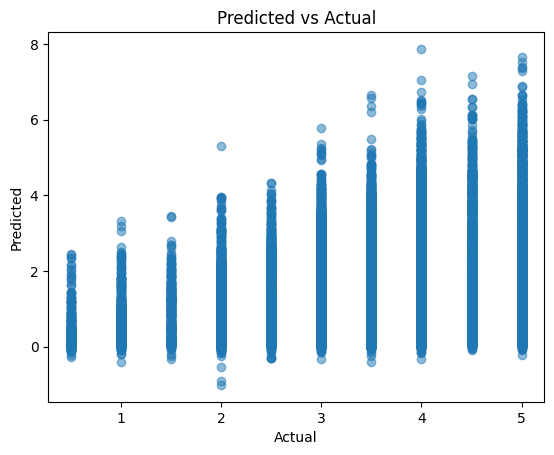

In [24]:
plt.scatter(y_true, y_pred, alpha=0.5)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual")
plt.show()

## Heatmap of original vs reconstructed matrix

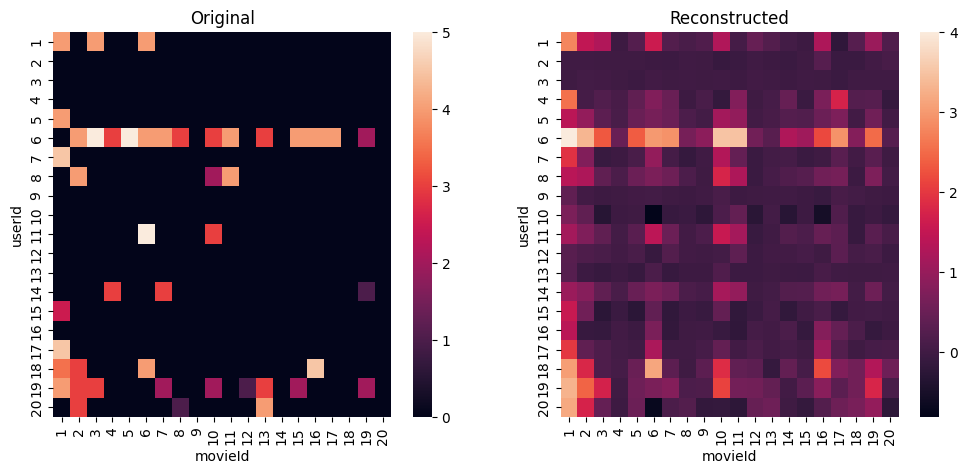

In [23]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.heatmap(user_item_matrix_filled.iloc[:20, :20])
plt.title("Original")

plt.subplot(1,2,2)
sns.heatmap(reconstructed_df.iloc[:20, :20])
plt.title("Reconstructed")

plt.show()

## Overfitting vs Underfitting

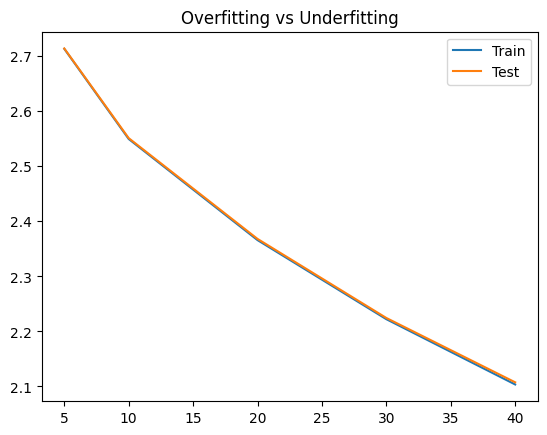

In [20]:
k_values = [5, 10, 20, 30, 40]
train_errors = []
test_errors = []

for k in k_values:
    svd = TruncatedSVD(n_components=k)
    U = svd.fit_transform(user_item_matrix_filled)
    VT = svd.components_
    recon = np.dot(U, VT)
    recon_df = pd.DataFrame(recon, index=user_item_matrix.index, columns=user_item_matrix.columns)

    train_pred, train_true = [], []
    for row in train_data.itertuples():
        if row.userId in recon_df.index and row.movieId in recon_df.columns:
            train_true.append(row.rating)
            train_pred.append(recon_df.loc[row.userId, row.movieId])

    test_pred, test_true = [], []
    for row in test_data.itertuples():
        if row.userId in recon_df.index and row.movieId in recon_df.columns:
            test_true.append(row.rating)
            test_pred.append(recon_df.loc[row.userId, row.movieId])

    train_errors.append(np.sqrt(mean_squared_error(train_true, train_pred)))
    test_errors.append(np.sqrt(mean_squared_error(test_true, test_pred)))

plt.plot(k_values, train_errors, label="Train")
plt.plot(k_values, test_errors, label="Test")
plt.legend()
plt.title("Overfitting vs Underfitting")
plt.show()

## Dimensionality Reduction Impact

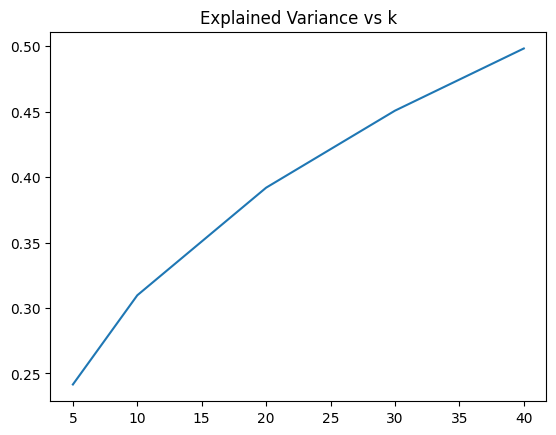

In [21]:
explained_variance = []

for k in k_values:
    svd = TruncatedSVD(n_components=k)
    svd.fit(user_item_matrix_filled)
    explained_variance.append(svd.explained_variance_ratio_.sum())

plt.plot(k_values, explained_variance)
plt.title("Explained Variance vs k")
plt.show()